# Algoritmos cuánticos del libro

> Una guía visual y ejecutable con Qiskit

Este cuaderno reúne los algoritmos trabajados en el proyecto. Cada sección combina la idea matemática, el circuito y una simulación de mediciones.

**Contenido:** phase kickback, Deutsch, Deutsch-Jozsa, Bernstein-Vazirani, Simon y Grover.

## Antes de empezar

Se utilizan dos registros: qubits cuánticos, que pueden estar en superposición, y bits clásicos, que almacenan las mediciones. Para reproducir el cuaderno, selecciona como kernel el entorno `qiskit-env`.

Los porcentajes pueden variar ligeramente entre ejecuciones porque las mediciones son aleatorias; las conclusiones del algoritmo permanecen.

In [1]:
from collections import Counter

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()

def ejecutar(circuito, shots=1024):
    """Ejecuta un circuito y devuelve sus resultados ordenados."""
    resultado = simulator.run(circuito, shots=shots).result()
    return resultado.get_counts()

def mostrar(circuito, shots=1024):
    """Imprime el circuito, muestra su dibujo gráfico y devuelve las mediciones."""
    print(circuito.draw())
    display(circuito.draw(output="mpl"))
    return ejecutar(circuito, shots)

## 1. Phase kickback

Cuando el qubit objetivo está en $|-> = (|0>-|1>)/\sqrt{2}$, una CNOT transforma la información de la entrada en una fase. Esta propiedad es el mecanismo que utilizan varios de los algoritmos siguientes.

     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 


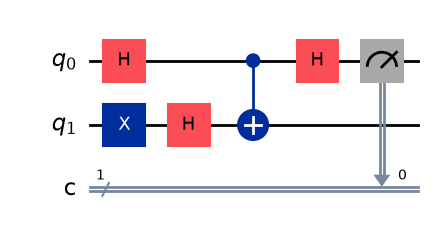

{'1': 1024}

In [2]:
kickback = QuantumCircuit(2, 1)
kickback.h(0)
kickback.x(1)
kickback.h(1)
kickback.cx(0, 1)
kickback.h(0)
kickback.measure(0, 0)

mostrar(kickback)

El resultado esperado es `1` con probabilidad cercana al 100 %: la fase negativa del segundo qubit se ha transferido al primero.

## 2. Algoritmo de Deutsch

Deutsch decide si una función $f: \{0,1\} \rightarrow \{0,1\}$ es constante o balanceada usando una sola consulta al oráculo. Aquí se prueban ambos casos.

     ┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ H ├┤M├
     ├───┤├───┤└╥┘
q_1: ┤ X ├┤ H ├─╫─
     └───┘└───┘ ║ 
c: 1/═══════════╩═
                0 


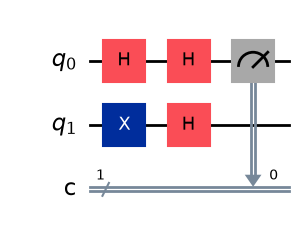

Constante: {'0': 1024}
     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 


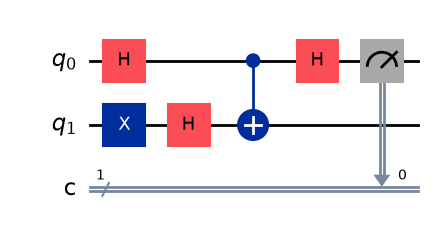

Balanceada: {'1': 1024}


In [3]:
def deutsch(oraculo):
    circuito = QuantumCircuit(2, 1)
    circuito.x(1)
    circuito.h([0, 1])
    oraculo(circuito)
    circuito.h(0)
    circuito.measure(0, 0)
    return circuito

def oraculo_constante(circuito):
    pass

def oraculo_balanceado(circuito):
    circuito.cx(0, 1)

deutsch_constante = deutsch(oraculo_constante)
deutsch_balanceado = deutsch(oraculo_balanceado)
print("Constante:", mostrar(deutsch_constante))
print("Balanceada:", mostrar(deutsch_balanceado))

Medir `0` identifica una función constante y medir `1` una función balanceada.

## 3. Deutsch-Jozsa

Deutsch-Jozsa extiende la idea a $n$ bits. Si el oráculo es constante, la medición devuelve `000`; si es balanceado, el resultado no es la cadena de ceros.

     ┌───┐┌───┐┌─┐      
q_0: ┤ H ├┤ H ├┤M├──────
     ├───┤├───┤└╥┘┌─┐   
q_1: ┤ H ├┤ H ├─╫─┤M├───
     ├───┤├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├┤ H ├─╫──╫─┤M├
     ├───┤├───┤ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─╫──╫──╫─
     └───┘└───┘ ║  ║  ║ 
c: 3/═══════════╩══╩══╩═
                0  1  2 


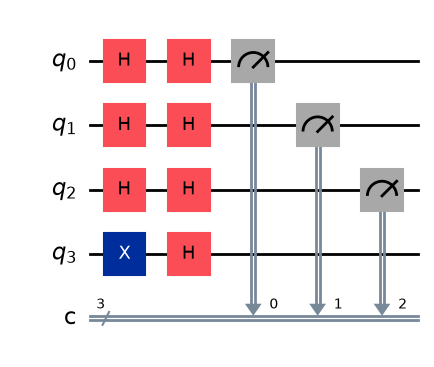

Constante: {'000': 1024}
     ┌───┐          ┌───┐     ┌─┐           
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐   
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘┌─┐
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐ ║ └───┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─╫───────╫──╫─
     └───┘└───┘└───┘└───┘└───┘ ║       ║  ║ 
c: 3/══════════════════════════╩═══════╩══╩═
                               0       1  2 


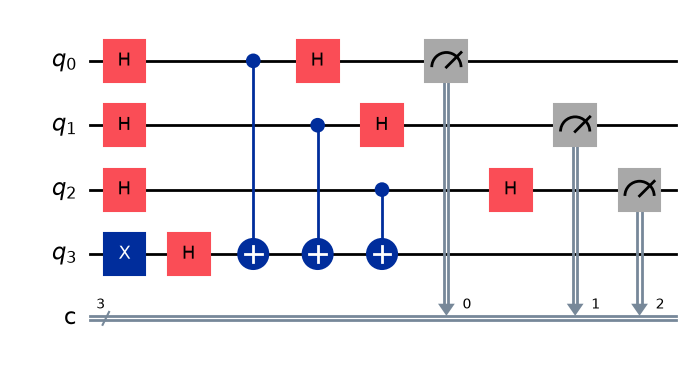

Balanceado: {'111': 1024}


In [4]:
def deutsch_jozsa(oraculo, n=3):
    circuito = QuantumCircuit(n + 1, n)
    circuito.x(n)
    circuito.h(range(n + 1))
    oraculo(circuito, n)
    circuito.h(range(n))
    circuito.measure(range(n), range(n))
    return circuito

def dj_constante(circuito, n):
    pass

def dj_balanceado(circuito, n):
    for qubit in range(n):
        circuito.cx(qubit, n)

print("Constante:", mostrar(deutsch_jozsa(dj_constante)))
print("Balanceado:", mostrar(deutsch_jozsa(dj_balanceado)))

## 4. Bernstein-Vazirani

El oráculo calcula $f(x)=s\cdot x \pmod 2$. El algoritmo recupera toda la cadena secreta $s$ en una sola consulta. En este ejemplo, $s=101$.

     ┌───┐          ┌───┐          ┌─┐   
q_0: ┤ H ├───────■──┤ H ├──────────┤M├───
     ├───┤┌───┐  │  └┬─┬┘          └╥┘   
q_1: ┤ H ├┤ H ├──┼───┤M├────────────╫────
     ├───┤└───┘  │   └╥┘      ┌───┐ ║ ┌─┐
q_2: ┤ H ├───────┼────╫────■──┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐  ║  ┌─┴─┐└───┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├──╫──┤ X ├──────╫──╫─
     └───┘└───┘└───┘  ║  └───┘      ║  ║ 
c: 3/═════════════════╩═════════════╩══╩═
                      1             0  2 


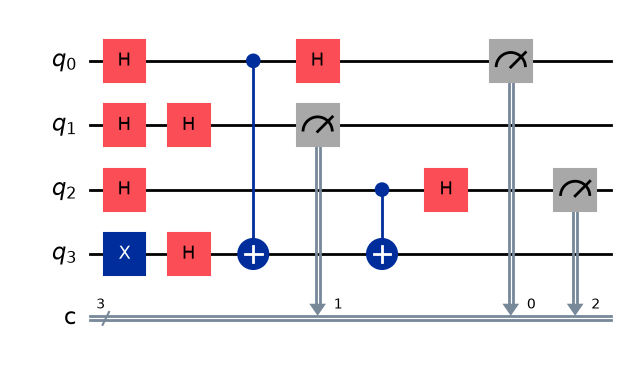

Cadena recuperada: {'101': 1024}


In [5]:
def bernstein_vazirani(secreto):
    n = len(secreto)
    circuito = QuantumCircuit(n + 1, n)
    circuito.x(n)
    circuito.h(range(n + 1))
    for indice, bit in enumerate(reversed(secreto)):
        if bit == "1":
            circuito.cx(indice, n)
    circuito.h(range(n))
    circuito.measure(range(n), range(n))
    return circuito

bv = bernstein_vazirani("101")
print("Cadena recuperada:", mostrar(bv))

## 5. Algoritmo de Simon

Simon encuentra una cadena no nula $s$ tal que $f(x)=f(x\oplus s)$. Para que el circuito sea transparente, usamos $s=101$ y un oráculo lineal que produce las ecuaciones $y\cdot s=0$. Repetir las mediciones permite resolverlas.

     ┌───┐     ┌───┐          ┌─┐      
q_0: ┤ H ├──■──┤ H ├──────────┤M├──────
     ├───┤  │  └───┘┌───┐     └╥┘┌─┐   
q_1: ┤ H ├──┼────■──┤ H ├──────╫─┤M├───
     ├───┤  │    │  └───┘┌───┐ ║ └╥┘┌─┐
q_2: ┤ H ├──┼────┼────■──┤ H ├─╫──╫─┤M├
     └───┘┌─┴─┐  │  ┌─┴─┐└───┘ ║  ║ └╥┘
q_3: ─────┤ X ├──┼──┤ X ├──────╫──╫──╫─
          └───┘┌─┴─┐└───┘      ║  ║  ║ 
q_4: ──────────┤ X ├───────────╫──╫──╫─
               └───┘           ║  ║  ║ 
q_5: ──────────────────────────╫──╫──╫─
                               ║  ║  ║ 
c: 3/══════════════════════════╩══╩══╩═
                               0  1  2 


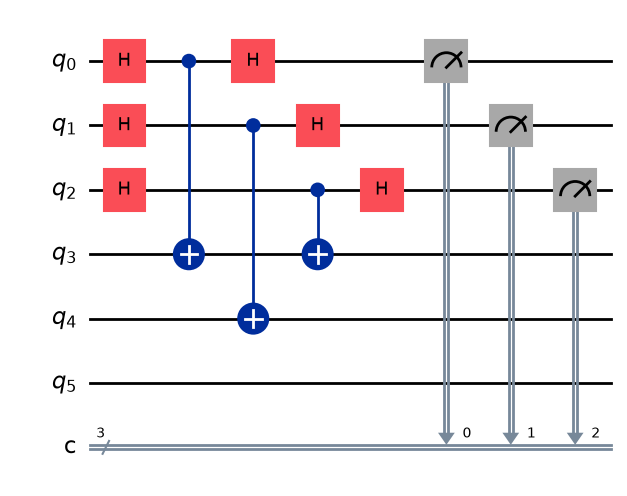

Ecuaciones observadas: {'000': 244, '010': 270, '101': 251, '111': 259}
Cada cadena observada cumple y · 101 = 0 (mod 2).


In [6]:
def simon(secreto):
    n = len(secreto)
    circuito = QuantumCircuit(2 * n, n)
    circuito.h(range(n))
    # Para s=101: f(x) = (x0 XOR x2, x1, 0).
    circuito.cx(0, n)
    circuito.cx(2, n)
    circuito.cx(1, n + 1)
    circuito.h(range(n))
    circuito.measure(range(n), range(n))
    return circuito

simon_circuito = simon("101")
print("Ecuaciones observadas:", mostrar(simon_circuito))
print("Cada cadena observada cumple y · 101 = 0 (mod 2).")

## 6. Grover

Grover amplifica la probabilidad de una solución marcada. En el ejemplo de dos qubits, el oráculo marca `11` y una iteración del difusor concentra la medición en esa cadena.

     ┌───┐   ┌───┐┌───┐   ┌───┐┌───┐┌─┐   
q_0: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├┤M├───
     ├───┤ │ ├───┤├───┤ │ ├───┤├───┤└╥┘┌─┐
q_1: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├─╫─┤M├
     └───┘   └───┘└───┘   └───┘└───┘ ║ └╥┘
c: 2/════════════════════════════════╩══╩═
                                     0  1 


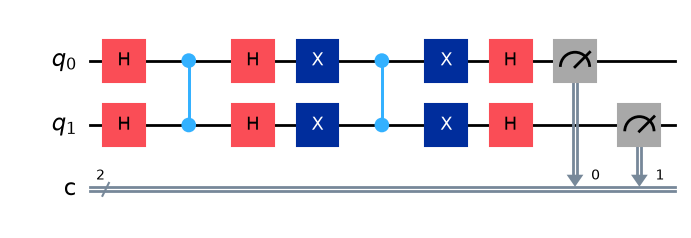

Elemento encontrado: {'11': 1024}


In [7]:
def grover_2_qubits():
    circuito = QuantumCircuit(2, 2)
    circuito.h([0, 1])
    # Oráculo: cambia la fase de |11>.
    circuito.cz(0, 1)
    # Difusor de Grover.
    circuito.h([0, 1])
    circuito.x([0, 1])
    circuito.cz(0, 1)
    circuito.x([0, 1])
    circuito.h([0, 1])
    circuito.measure([0, 1], [0, 1])
    return circuito

grover_circuito = grover_2_qubits()
print("Elemento encontrado:", mostrar(grover_circuito))

## Resumen

| Algoritmo | Problema | Idea clave |
|---|---|---|
| Phase kickback | Transferir una fase | Estado $|->$ |
| Deutsch | Constante o balanceada | Una consulta |
| Deutsch-Jozsa | Constante o balanceada en $n$ bits | Interferencia global |
| Bernstein-Vazirani | Encontrar una cadena secreta | Codificación de fases |
| Simon | Encontrar un periodo XOR | Ecuaciones lineales |
| Grover | Buscar un elemento marcado | Amplificación de amplitud |

La idea común es preparar una superposición, consultar un oráculo y usar interferencia para convertir información cuántica en una medición interpretable.